In [1]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.3/934.3 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 48.5 MB/s eta 0:00:00


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aklimarimi/8-facial-expressions-for-yolo")

print("Path to dataset files:", path)

100%|██████████| 3.77G/3.77G [02:54<00:00, 23.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/aklimarimi/8-facial-expressions-for-yolo/versions/4


In [3]:
import os
import torch
import torchvision
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torchvision.transforms as tt
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
%matplotlib inline

DATA_DIR = '/root/.cache/kagglehub/datasets/aklimarimi/8-facial-expressions-for-yolo/versions/4/9 Facial Expressions you need'
train = os.listdir(os.path.join(DATA_DIR,'train'))
test = os.listdir(os.path.join(DATA_DIR,'test'))
val=os.listdir(os.path.join(DATA_DIR,'valid'))
print(f'Train - {train}')
print(f'Test - {test}')
print(f'Val - {val}')

Train - ['labels', 'images']
Test - ['labels', 'images']
Val - ['labels', 'images']


In [4]:
import os
import cv2
import numpy as np
from tensorflow.keras.utils import to_categorical

IMG_SIZE = 48
EMOTIONS = ['Happy', 'Sad', 'Angry', 'Surprised', 'Neutral', 'Disgusted', 'Fear', 'Sleepy', 'Contempt']  # update based on your labels
emotion_to_idx = {e: i for i, e in enumerate(EMOTIONS)}
idx_to_emotion = {i: e for i, e in enumerate(EMOTIONS)} # Add mapping from index to emotion

def load_data(folder_path):
    image_dir = os.path.join(folder_path, 'images')
    label_dir = os.path.join(folder_path, 'labels')

    images = []
    labels = []

    # Get list of label files
    label_files = sorted([f for f in os.listdir(label_dir) if f.endswith('.txt')])

    for label_fname in label_files:
        image_fname = label_fname.replace('.txt', '.jpg')
        image_path = os.path.join(image_dir, image_fname)
        label_path = os.path.join(label_dir, label_fname)

        # Check if the corresponding image file exists
        if not os.path.exists(image_path):
            print(f"Warning: Image file not found for label file {label_path}. Skipping.")
            continue

        # Load image in grayscale
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"Warning: Could not read image file {image_path}. Skipping.")
            continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))  # Resize to 48×48
        images.append(img)

        # Load and parse label from YOLO format
        with open(label_path, 'r') as f:
            label_content = f.read().strip()
            # Assuming the first number in the line is the class ID
            try:
                class_id = int(label_content.split()[0])
                labels.append(class_id)
            except (ValueError, IndexError):
                print(f"Warning: Could not parse label from file {label_path}. Content: '{label_content}'. Skipping.")
                images.pop() # Remove the image if label parsing fails
                continue


    images = np.array(images)
    labels = np.array(labels)
    return images, labels


# Load full data from train folder
images, labels = load_data(os.path.join(DATA_DIR, 'test'))

# Normalize pixel values to be between 0 and 1
images = images / 255.0

# Reduce dataset size
n_train = 5000
n_test = 3000

train_images = images[:n_train]
train_labels = labels[:n_train]
test_images = images[-n_test:]
test_labels = labels[-n_test:]

# Add grayscale channel dimension: (N, 48, 48, 1)
train_images = np.expand_dims(train_images, axis=-1)
test_images = np.expand_dims(test_images, axis=-1)

# One-hot encode the labels
train_labels_categorical = to_categorical(train_labels, num_classes=len(EMOTIONS))
test_labels_categorical = to_categorical(test_labels, num_classes=len(EMOTIONS))

# Final checks
print(f"Train images shape: {train_images.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Train labels shape: {train_labels_categorical.shape}")
print(f"Test labels shape: {test_labels_categorical.shape}")

Train images shape: (1700, 48, 48, 1)
Test images shape: (1700, 48, 48, 1)
Train labels shape: (1700, 9)
Test labels shape: (1700, 9)


/usr/local/lib/python3.12/dist-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.2 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(



=== Running for 12 Qubits ===

Quantum Circuit for 12 Qubits:


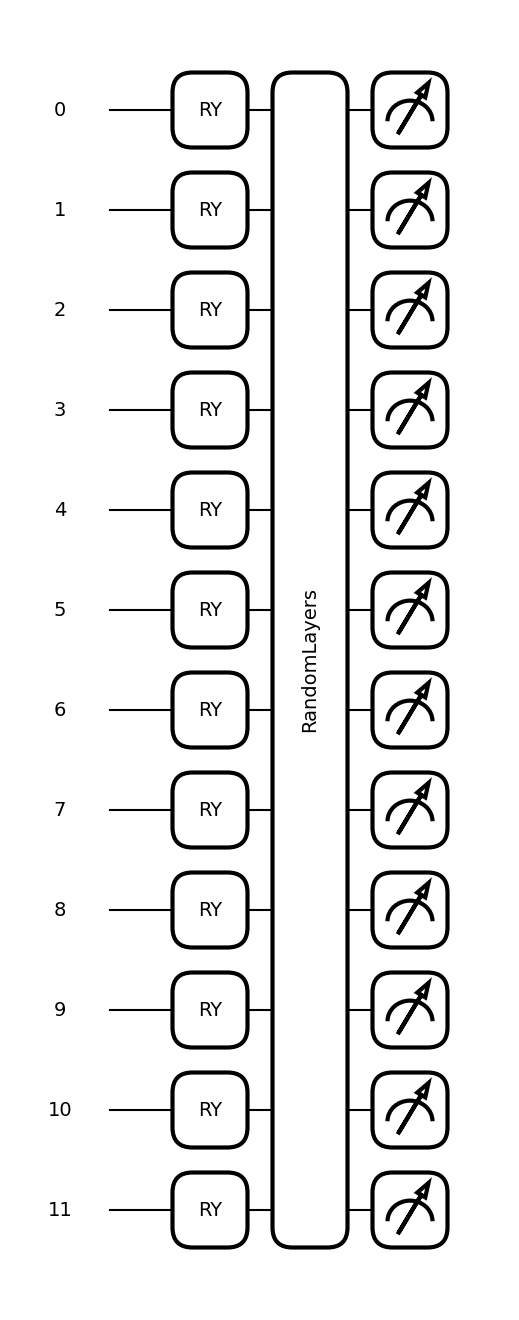

Quantum preprocessing (train)...
Quantum preprocessing (test)...


In [5]:
import pennylane as qml
from pennylane import numpy as np
from pennylane.templates import RandomLayers
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# Number of classes (for this dataset)
num_classes = len(EMOTIONS)

# Define qubit patch sizes
qubit_patch_shapes = {
    4: (2, 2),
    6: (3, 2),
    8: (4, 2),
    10: (5, 2),
    12: (4, 3),
}

# ------------------ Quantum Circuit Creation -------------------
def create_circuit(n_qubits, n_layers=1):
    dev = qml.device("default.qubit", wires=n_qubits)
    rand_params = np.random.uniform(high=2*np.pi, size=(n_layers, n_qubits))

    @qml.qnode(dev)
    def circuit(phi):
        # Encode classical data into qubits
        for j in range(n_qubits):
            qml.RY(np.pi * phi[j], wires=j)
        RandomLayers(rand_params, wires=range(n_qubits))
        return [qml.expval(qml.PauliZ(j)) for j in range(n_qubits)]

    return circuit

# ------------------ Quantum Convolution -------------------
def quanv(image, circuit, patch_h, patch_w):
    out_h = (image.shape[0] - patch_h) // 2 + 1
    out_w = (image.shape[1] - patch_w) // 2 + 1
    n_qubits = patch_h * patch_w
    out = np.zeros((out_h, out_w, n_qubits))
    for j in range(0, image.shape[0] - patch_h + 1, 2):
        for k in range(0, image.shape[1] - patch_w + 1, 2):
            patch = image[j:j+patch_h, k:k+patch_w, 0].flatten()
            q_results = circuit(patch)
            out[j//2, k//2, :] = q_results
    return out

def build_model(input_shape, num_classes):
    model = keras.Sequential([
        keras.layers.Flatten(input_shape=input_shape),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

results = {}
n_qubits=12

print(f"\n=== Running for {n_qubits} Qubits ===")
patch_h, patch_w = qubit_patch_shapes[n_qubits]
circuit = create_circuit(n_qubits)

# Show quantum circuit diagram
print(f"\nQuantum Circuit for {n_qubits} Qubits:")
fig, ax = qml.draw_mpl(circuit)(np.random.rand(n_qubits))
plt.show()

# Quantum preprocessing
print("Quantum preprocessing (train)...")
q_train_images = np.array([quanv(img, circuit, patch_h, patch_w) for img in train_images])
print("Quantum preprocessing (test)...")
q_test_images = np.array([quanv(img, circuit, patch_h, patch_w) for img in test_images])

 Running Quantum CNN for Seed = 0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/250
213/213 - 8s - 37ms/step - accuracy: 0.2300 - loss: 2.4731 - val_accuracy: 0.3800 - val_loss: 1.7250
Epoch 2/250
213/213 - 3s - 13ms/step - accuracy: 0.3347 - loss: 1.8705 - val_accuracy: 0.4694 - val_loss: 1.5232
Epoch 3/250
213/213 - 5s - 24ms/step - accuracy: 0.4047 - loss: 1.6321 - val_accuracy: 0.5600 - val_loss: 1.2956
Epoch 4/250
213/213 - 4s - 18ms/step - accuracy: 0.4594 - loss: 1.5061 - val_accuracy: 0.6165 - val_loss: 1.1848
Epoch 5/250
213/213 - 3s - 14ms/step - accuracy: 0.5018 - loss: 1.3537 - val_accuracy: 0.6665 - val_loss: 1.0146
Epoch 6/250
213/213 - 3s - 14ms/step - accuracy: 0.5576 - loss: 1.2160 - val_accuracy: 0.7006 - val_loss: 0.8972
Epoch 7/250
213/213 - 3s - 14ms/step - accuracy: 0.5953 - loss: 1.1415 - val_accuracy: 0.7112 - val_loss: 0.8388
Epoch 8/250
213/213 - 4s - 18ms/step - accuracy: 0.6053 - loss: 1.0538 - val_accuracy: 0.7524 - val_loss: 0.7560
Epoch 9/250
213/213 - 3s - 14ms/step - accuracy: 0.6488 - loss: 0.9673 - val_accuracy: 0.7571 - 

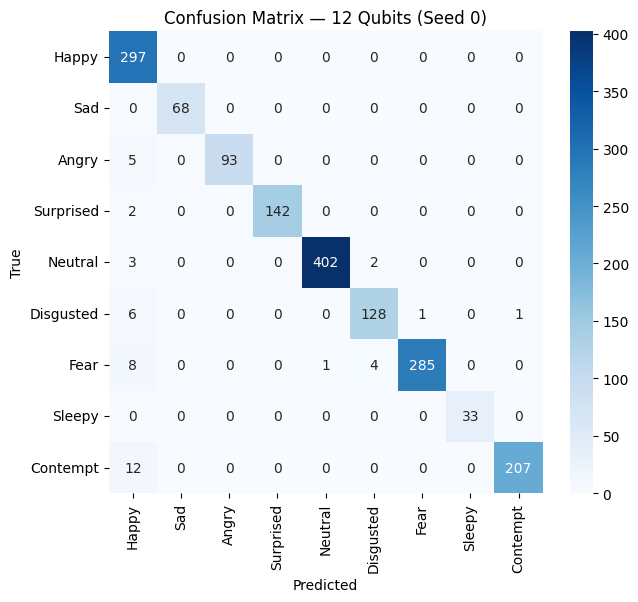

 Running Quantum CNN for Seed = 1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/250
213/213 - 5s - 22ms/step - accuracy: 0.2424 - loss: 2.4013 - val_accuracy: 0.3465 - val_loss: 1.8135
Epoch 2/250
213/213 - 4s - 18ms/step - accuracy: 0.3265 - loss: 1.9098 - val_accuracy: 0.4606 - val_loss: 1.6097
Epoch 3/250
213/213 - 3s - 13ms/step - accuracy: 0.4041 - loss: 1.6918 - val_accuracy: 0.5206 - val_loss: 1.3810
Epoch 4/250
213/213 - 3s - 12ms/step - accuracy: 0.4547 - loss: 1.5204 - val_accuracy: 0.5647 - val_loss: 1.2574
Epoch 5/250
213/213 - 3s - 16ms/step - accuracy: 0.5106 - loss: 1.3829 - val_accuracy: 0.6335 - val_loss: 1.0649
Epoch 6/250
213/213 - 3s - 13ms/step - accuracy: 0.5400 - loss: 1.2765 - val_accuracy: 0.6812 - val_loss: 0.9586
Epoch 7/250
213/213 - 3s - 14ms/step - accuracy: 0.5576 - loss: 1.1699 - val_accuracy: 0.6935 - val_loss: 0.9250
Epoch 8/250
213/213 - 3s - 13ms/step - accuracy: 0.5965 - loss: 1.0949 - val_accuracy: 0.7288 - val_loss: 0.7912
Epoch 9/250
213/213 - 4s - 18ms/step - accuracy: 0.6465 - loss: 0.9954 - val_accuracy: 0.7653 - 

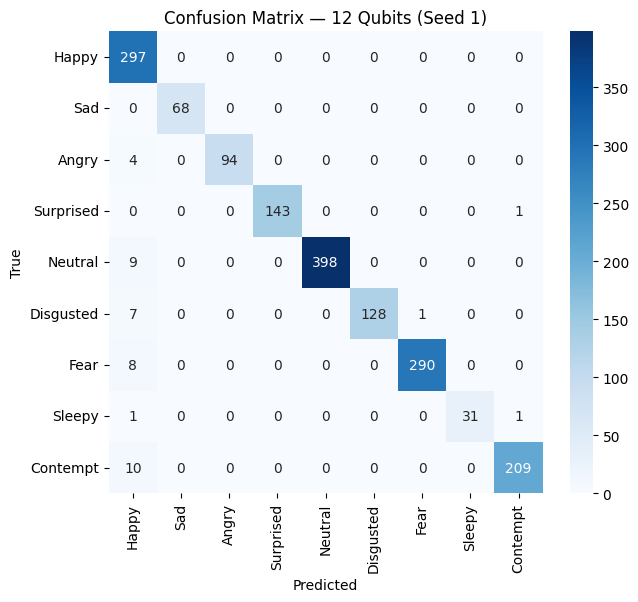

 Running Quantum CNN for Seed = 2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/250
213/213 - 5s - 23ms/step - accuracy: 0.2188 - loss: 2.3720 - val_accuracy: 0.3606 - val_loss: 1.7845
Epoch 2/250
213/213 - 4s - 19ms/step - accuracy: 0.3294 - loss: 1.8394 - val_accuracy: 0.4476 - val_loss: 1.5129
Epoch 3/250
213/213 - 3s - 14ms/step - accuracy: 0.4118 - loss: 1.6649 - val_accuracy: 0.5694 - val_loss: 1.2781
Epoch 4/250
213/213 - 4s - 17ms/step - accuracy: 0.4800 - loss: 1.4663 - val_accuracy: 0.5953 - val_loss: 1.2223
Epoch 5/250
213/213 - 3s - 16ms/step - accuracy: 0.5059 - loss: 1.3452 - val_accuracy: 0.6588 - val_loss: 1.0784
Epoch 6/250
213/213 - 3s - 15ms/step - accuracy: 0.5447 - loss: 1.2454 - val_accuracy: 0.7041 - val_loss: 0.9089
Epoch 7/250
213/213 - 3s - 15ms/step - accuracy: 0.6247 - loss: 1.0595 - val_accuracy: 0.7453 - val_loss: 0.7933
Epoch 8/250
213/213 - 4s - 18ms/step - accuracy: 0.6276 - loss: 1.0406 - val_accuracy: 0.7547 - val_loss: 0.7474
Epoch 9/250
213/213 - 3s - 14ms/step - accuracy: 0.6647 - loss: 0.9358 - val_accuracy: 0.7741 - 

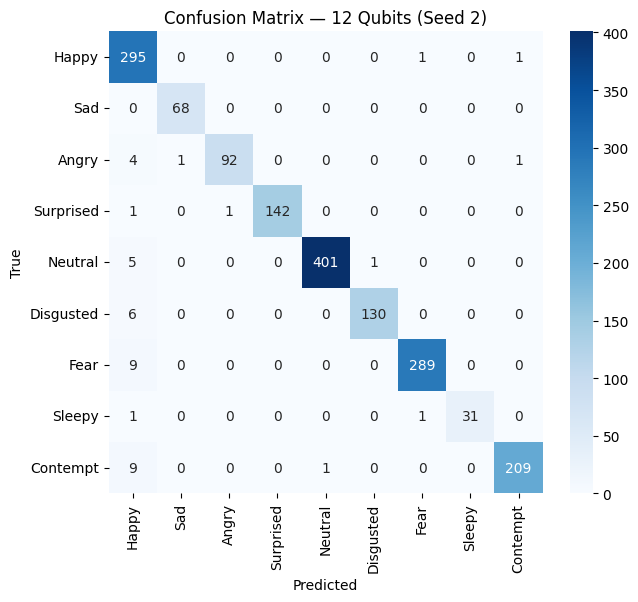

 Running Quantum CNN for Seed = 3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/250
213/213 - 4s - 21ms/step - accuracy: 0.2247 - loss: 2.4595 - val_accuracy: 0.3912 - val_loss: 1.7190
Epoch 2/250
213/213 - 3s - 14ms/step - accuracy: 0.3106 - loss: 1.8668 - val_accuracy: 0.4824 - val_loss: 1.4813
Epoch 3/250
213/213 - 3s - 14ms/step - accuracy: 0.4018 - loss: 1.6463 - val_accuracy: 0.5300 - val_loss: 1.3515
Epoch 4/250
213/213 - 4s - 17ms/step - accuracy: 0.4488 - loss: 1.5242 - val_accuracy: 0.5635 - val_loss: 1.2518
Epoch 5/250
213/213 - 3s - 14ms/step - accuracy: 0.4947 - loss: 1.3887 - val_accuracy: 0.6329 - val_loss: 1.0489
Epoch 6/250
213/213 - 3s - 13ms/step - accuracy: 0.5418 - loss: 1.2430 - val_accuracy: 0.6900 - val_loss: 0.9471
Epoch 7/250
213/213 - 3s - 15ms/step - accuracy: 0.5818 - loss: 1.1389 - val_accuracy: 0.7253 - val_loss: 0.8457
Epoch 8/250
213/213 - 4s - 18ms/step - accuracy: 0.6100 - loss: 1.0894 - val_accuracy: 0.7465 - val_loss: 0.7934
Epoch 9/250
213/213 - 3s - 14ms/step - accuracy: 0.6476 - loss: 1.0029 - val_accuracy: 0.7629 - 

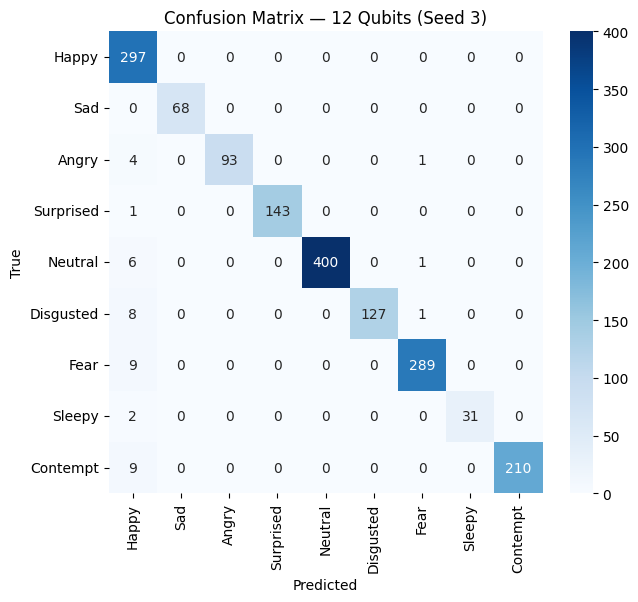

 Running Quantum CNN for Seed = 4


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/250
213/213 - 5s - 23ms/step - accuracy: 0.2288 - loss: 2.3677 - val_accuracy: 0.3665 - val_loss: 1.7545
Epoch 2/250
213/213 - 3s - 14ms/step - accuracy: 0.3247 - loss: 1.8772 - val_accuracy: 0.4506 - val_loss: 1.5682
Epoch 3/250
213/213 - 3s - 13ms/step - accuracy: 0.3618 - loss: 1.7127 - val_accuracy: 0.5200 - val_loss: 1.4033
Epoch 4/250
213/213 - 4s - 17ms/step - accuracy: 0.4388 - loss: 1.5217 - val_accuracy: 0.5829 - val_loss: 1.2026
Epoch 5/250
213/213 - 4s - 20ms/step - accuracy: 0.4924 - loss: 1.4458 - val_accuracy: 0.6229 - val_loss: 1.1394
Epoch 6/250
213/213 - 3s - 13ms/step - accuracy: 0.5335 - loss: 1.3014 - val_accuracy: 0.6876 - val_loss: 1.0054
Epoch 7/250
213/213 - 4s - 17ms/step - accuracy: 0.5653 - loss: 1.1834 - val_accuracy: 0.7282 - val_loss: 0.8597
Epoch 8/250
213/213 - 3s - 15ms/step - accuracy: 0.6100 - loss: 1.0627 - val_accuracy: 0.7424 - val_loss: 0.8062
Epoch 9/250
213/213 - 3s - 14ms/step - accuracy: 0.6312 - loss: 1.0041 - val_accuracy: 0.7459 - 

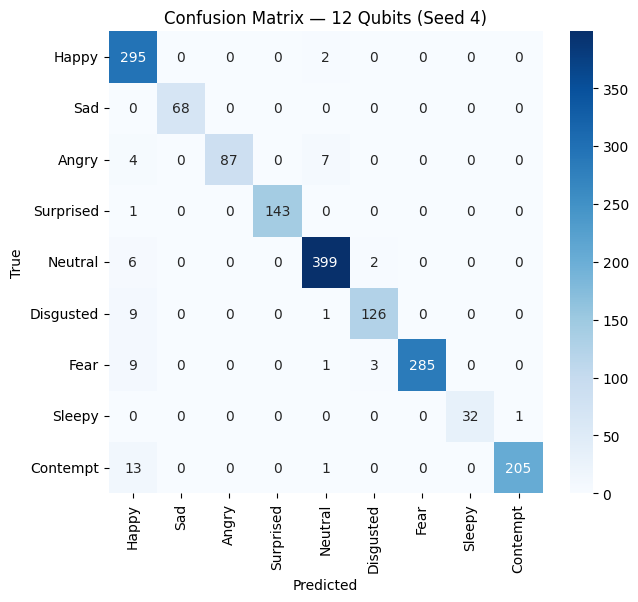


Final Summary Across Seeds (12 Qubits)
   Seed  Accuracy       AUC        F1
0     0  0.973529  0.999593  0.977334
1     1  0.975294  0.999754  0.977572
2     2  0.974706  0.999541  0.975261
3     3  0.975294  0.999596  0.977029
4     4  0.964706  0.999370  0.968228

Mean ± Std and 95% CI:
  Accuracy : 0.9727 ± 0.0045  (95% CI: [0.9671, 0.9783])
  Macro AUC: 0.9996 ± 0.0001  (95% CI: [0.9994, 0.9997])
  Macro F1 : 0.9751 ± 0.0039  (95% CI: [0.9702, 0.9800])


In [6]:
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as st


n_qubits = 12
num_classes = len(EMOTIONS)
seeds = [0, 1, 2, 3, 4]


results = []

for seed in seeds:
    print(f" Running Quantum CNN for Seed = {seed}")

    # Fix random seed for reproducibility
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # Build and train model
    model = build_model(q_train_images.shape[1:], num_classes)
    history = model.fit(q_train_images, train_labels, validation_data=(q_test_images, test_labels),
                        epochs=250, batch_size=8, verbose=2)

    # Predictions
    y_pred_prob = model.predict(q_test_images)
    y_pred = np.argmax(y_pred_prob, axis=1)

    # Accuracy
    acc = np.mean(y_pred == test_labels)

    # One-hot encode labels for AUC
    y_true_onehot = keras.utils.to_categorical(test_labels, num_classes=num_classes)
    try:
        macro_auc = roc_auc_score(y_true_onehot, y_pred_prob, multi_class='ovr', average='macro')
    except ValueError:
        macro_auc = np.nan

    # Macro F1
    macro_f1 = f1_score(test_labels, y_pred, average='macro')

    print(f"\nSeed {seed} Results:")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Macro AUC: {macro_auc:.4f}")
    print(f"  Macro F1 : {macro_f1:.4f}")

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(test_labels, y_pred, target_names=EMOTIONS, zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(test_labels, y_pred)
    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=EMOTIONS, yticklabels=EMOTIONS)
    plt.title(f'Confusion Matrix — 12 Qubits (Seed {seed})')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # Store results
    results.append({
        'Seed': seed,
        'Accuracy': acc,
        'AUC': macro_auc,
        'F1': macro_f1
    })


results_df = pd.DataFrame(results)
mean_acc, std_acc = results_df['Accuracy'].mean(), results_df['Accuracy'].std(ddof=1)
mean_auc, std_auc = results_df['AUC'].mean(), results_df['AUC'].std(ddof=1)
mean_f1, std_f1 = results_df['F1'].mean(), results_df['F1'].std(ddof=1)

# 95% Confidence Intervals
ci_acc = st.t.interval(0.95, len(results_df)-1, loc=mean_acc, scale=st.sem(results_df['Accuracy']))
ci_auc = st.t.interval(0.95, len(results_df)-1, loc=mean_auc, scale=st.sem(results_df['AUC']))
ci_f1 = st.t.interval(0.95, len(results_df)-1, loc=mean_f1, scale=st.sem(results_df['F1']))

print("\nFinal Summary Across Seeds (12 Qubits)")
print(results_df)
print(f"\nMean ± Std and 95% CI:")
print(f"  Accuracy : {mean_acc:.4f} ± {std_acc:.4f}  (95% CI: [{ci_acc[0]:.4f}, {ci_acc[1]:.4f}])")
print(f"  Macro AUC: {mean_auc:.4f} ± {std_auc:.4f}  (95% CI: [{ci_auc[0]:.4f}, {ci_auc[1]:.4f}])")
print(f"  Macro F1 : {mean_f1:.4f} ± {std_f1:.4f}  (95% CI: [{ci_f1[0]:.4f}, {ci_f1[1]:.4f}])")
